# m-out-of-n Bootstrap Scaling Experiment

Does scaling the m-out-of-n bootstrap correction by $\sqrt{m/N}$ fix overcorrection?

In [1]:
%run _dev_setup.py

🔁 Autoreload is ON (IPython detected).
✅ Using winners_curse from: /Users/iamsikun/Desktop/research/winners-curse/src/winners_curse


In [10]:
from winners_curse.analysis import plot_snr_wc_comparison, plot_sample_size_wc_comparison, tabulate_sample_size_moon_wc

In [3]:
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'serif'
tick_label_size = 12
axis_label_size = 14
legend_label_size = 12
title_size = 16

## Load Results

In [ ]:
result_dir = '../results/ab_test_moon_scaling_20260326_113057/'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    results = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    config = json.load(f)

In [5]:
results[(500, (1, 1.005))].keys()

dict_keys(['effect_est_arr', 'nc_wc_arr', 'nc_val_est_arr', 'nc_val_true_arr', 'nc_selection_arr', 'standard_bootstrap_wc_arr', 'standard_bootstrap_val_est_arr', 'moon_070_unscaled_wc_arr', 'moon_070_unscaled_val_est_arr', 'moon_070_scaled_wc_arr', 'moon_070_scaled_val_est_arr', 'moon_080_unscaled_wc_arr', 'moon_080_unscaled_val_est_arr', 'moon_080_scaled_wc_arr', 'moon_080_scaled_val_est_arr', 'moon_095_unscaled_wc_arr', 'moon_095_unscaled_val_est_arr', 'moon_095_scaled_wc_arr', 'moon_095_scaled_val_est_arr'])

In [6]:
# Estimator display names
estimator_keys = [
    'nc',
    'standard_bootstrap',
    'moon_070_unscaled',
    'moon_070_scaled',
    'moon_080_unscaled',
    'moon_080_scaled',
    'moon_095_unscaled',
    'moon_095_scaled',
]

estimator_labels = {
    'nc': 'No Correction',
    'standard_bootstrap': 'Standard Bootstrap',
    'moon_070_unscaled': r'm-out-of-n ($\gamma$=0.7)',
    'moon_070_scaled': r'm-out-of-n ($\gamma$=0.7, scaled)',
    'moon_080_unscaled': r'm-out-of-n ($\gamma$=0.8)',
    'moon_080_scaled': r'm-out-of-n ($\gamma$=0.8, scaled)',
    'moon_095_unscaled': r'm-out-of-n ($\gamma$=0.95)',
    'moon_095_scaled': r'm-out-of-n ($\gamma$=0.95, scaled)',
}

sample_sizes = sorted(set(k[0] for k in results.keys()))
tau_tuples = sorted(set(k[1] for k in results.keys()))
print(f'Sample sizes: {sample_sizes}')
print(f'Tau tuples: {tau_tuples}')

Sample sizes: [500, 1000, 2500, 5000, 7500, 10000]
Tau tuples: [(1, 1.005), (1, 1.01), (1, 1.02)]


## SNR Comparison (Fixed Sample Size)

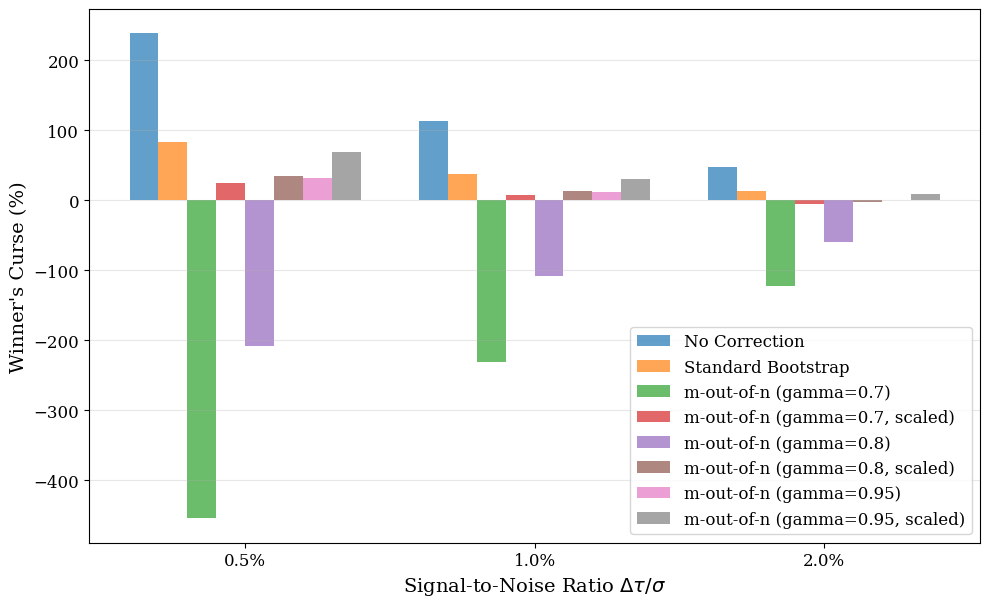

In [7]:
fixed_n = 2500

# Filter results for the fixed sample size, keyed by tau tuple
snr_results = {tau: res for (n, tau), res in results.items() if n == fixed_n}

plot_snr_wc_comparison(snr_results, config)

## Sample Size Comparison (Fixed SNR)

(1, 1.01)


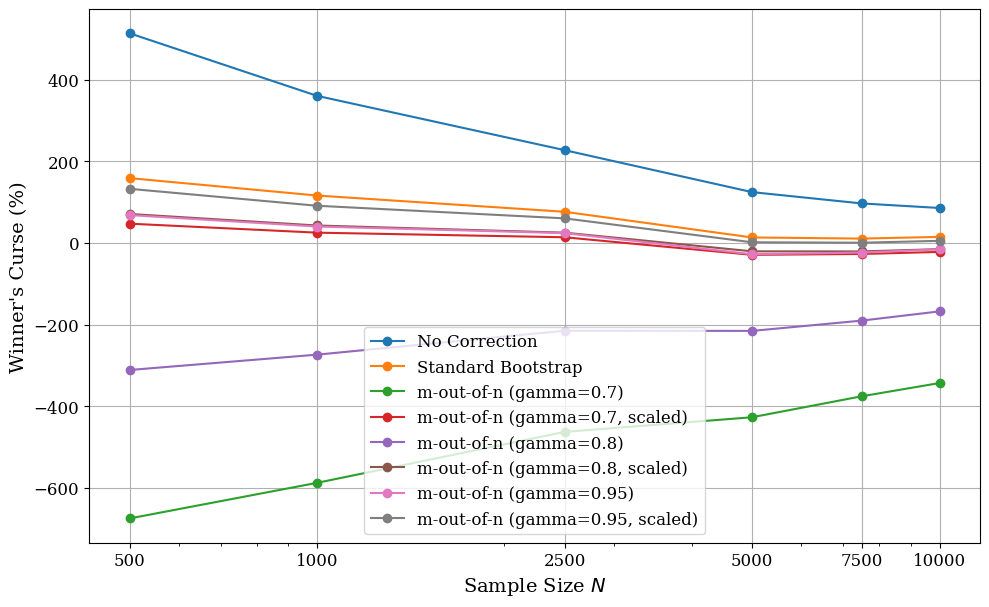

In [14]:
fixed_tau = tau_tuples[1]
print(fixed_tau)

# Filter results for the fixed SNR, keyed by sample size
sample_size_results = {n: res for (n, tau), res in results.items() if tau == fixed_tau}

plot_sample_size_wc_comparison(sample_size_results, config, sample_sizes)

In [15]:
moon_wc_table = tabulate_sample_size_moon_wc(sample_size_results, config, sample_sizes)
moon_wc_table.round(2)

No Correction Standard Bootstrap    γ=070           γ=080         \
                                             Unscaled Scaled Unscaled Scaled   
Sample Size                                                                    
500                514.49             159.10  -675.83  47.37  -311.62  71.15   
1000               361.03             116.42  -588.50  25.32  -274.00  42.88   
2500               227.69              76.53  -463.48  13.99  -215.24  25.30   
5000               124.75              13.54  -427.50 -29.09  -215.70 -20.49   
7500                96.99              10.77  -376.09 -26.97  -190.46 -20.78   
10000               85.85              14.94  -343.62 -21.95  -167.83 -15.11   

               γ=095          
            Unscaled  Scaled  
Sample Size                   
500            68.46  132.88  
1000           40.32   91.36  
2500           24.18   60.37  
5000          -27.50    1.70  
7500          -23.51    0.59  
10000         -15.60    5.27